# Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Diabetes Dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print(f"Dataset Shape: {df.shape}")
df.head()

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# Data Preprocessing & Scaling

In [2]:
# Separate features and target variable
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (Crucial for regularized linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Training features shape:", X_train.shape)

Preprocessing complete. Training features shape: (353, 10)


# Train and Evaluate Multiple Regression Algorithms

In [3]:
# Dictionary of regression models to compare
models = {
    "Linear Regression": (LinearRegression(), X_train_scaled, X_test_scaled),
    "Ridge Regression": (Ridge(alpha=1.0), X_train_scaled, X_test_scaled),
    "Lasso Regression": (Lasso(alpha=0.1), X_train_scaled, X_test_scaled),
    "Decision Tree": (DecisionTreeRegressor(random_state=42), X_train, X_test),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=42), X_train, X_test)
}

evaluation_results = []

for name, (model, X_tr, X_te) in models.items():
    # Train model
    model.fit(X_tr, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_te)
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        "Algorithm": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R² Score": r2
    })

# Compile results into a clean DataFrame
results_df = pd.DataFrame(evaluation_results).sort_values(by="R² Score", ascending=False)
display(results_df.style.background_gradient(cmap='Blues', subset=['R² Score']))

,Algorithm,MSE,RMSE,MAE,R² Score
2,Lasso Regression,2884.624289,53.708698,42.805234,0.455541
1,Ridge Regression,2892.014566,53.777454,42.811999,0.454147
5,Gradient Boosting,2898.436673,53.837131,44.603297,0.452934
0,Linear Regression,2900.193628,53.853446,42.794095,0.452603
4,Random Forest,2952.010589,54.332408,44.053034,0.442823
3,Decision Tree,4976.797753,70.546423,54.528090,0.060654


# Visualize Algorithm Performance Comparison

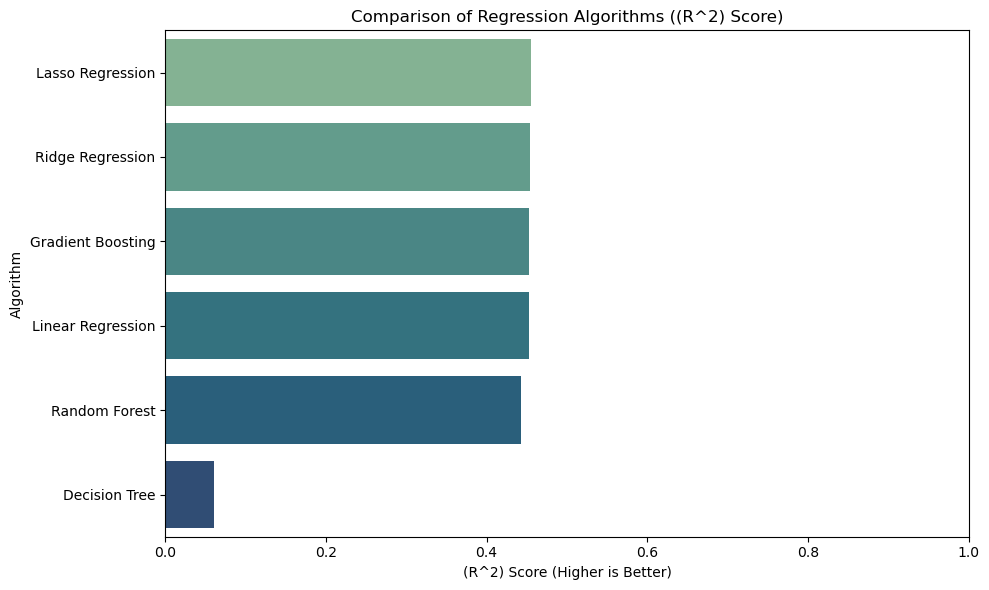

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='R² Score', 
    y='Algorithm', 
    data=results_df, 
    hue='Algorithm', 
    palette='crest', 
    legend=False
)
plt.title('Comparison of Regression Algorithms ((R^2) Score)')
plt.xlabel('(R^2) Score (Higher is Better)')
plt.ylabel('Algorithm')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# select the top-performing model based on the highest $R^2$ Score and lowest RMSE in our case Lasso Regression